# OfficeOasis Plant Co. study design and power analysis

**Author:** Arth Vijay
**Course:** AIPI 510, Week 6
**Cohort:** Online cohort

I propose a study to evaluate whether placing a small desk plant at an employee's workstation improves employee productivity compared with an empty desk. This notebook is a prospective study-planning analysis only; it does not use any new data from participants.

## Selected claim and research question

I selected the claim from OfficeOasis Plant Co.: 'Placing a small desk plant improves employee productivity scores compared to an empty desk.'

The outcome is continuous. I would measure a standardized office-task score based on task completion time, where larger values mean faster task completion. The research question is whether the mean productivity score is higher when a plant is present than when the desk is empty.

## Proposed study design and outcome

I propose an individually randomized, parallel-group experiment with a 1:1 allocation among adult office workers. Each participant attends one standardized work-task session at an otherwise identical workstation. In the plant condition, one small desk plant is placed on the desk. In the empty-desk condition, the workstation is otherwise identical but contains no plant.

I would keep the task, instructions, lighting, noise level, workstation setup, and time allowed constant across sessions. Randomization would occur independently for each participant, with a balanced schedule that avoids assigning all plant sessions to one room or all control sessions to another. Controls would not be seated adjacent to visible treatment plants. The primary outcome is a single employee-level productivity score, defined as negative completion time in minutes. This means a larger number indicates faster completion. I would also record errors as a secondary descriptive quality measure, but I would not treat a nonsignificant difference in errors as evidence that accuracy is equivalent.

## Null and alternative hypotheses

Let $\mu_P$ be the population mean productivity score with a plant and $\mu_E$ be the mean productivity score with an empty desk. Define $\Delta = \mu_P - \mu_E$.

- Null hypothesis: $H_0: \Delta \le 0$
- Alternative hypothesis: $H_1: \Delta > 0$

This says that a desk plant does not improve the mean productivity score and that the claim is directional: a plant should increase the score. Because the primary score is negative completion time, this is equivalent to saying the plant group completes work faster, so $\Delta$ also equals mean empty-desk completion time minus mean plant-group completion time. Positive $\Delta$ therefore means faster performance with the plant.

## Statistical test and rationale

The primary test will be a one-sided independent two-sample Student t-test under a common-variance model. I would analyze the plant and empty-desk groups as independent employee-level observations. This matches the design: one observation per person, parallel groups, and a prespecified directional improvement claim. The test is appropriate because the outcome is continuous, we have two independent groups, and the scientific question is whether the mean productivity score is higher in the plant condition.

I would use a significance threshold of $\alpha = 0.05$ and target power of 0.80 before data collection. The false-positive risk is controlled at the null boundary, and the design gives an 80% chance of rejecting $H_0$ under the selected effect and model assumptions if the true difference is as planned.

## Literature review and effect size

I used the study by Nieuwenhuis, Knight, Postmes, and Haslam (2014), 'The relative benefits of green versus lean office space: Three field experiments' (Journal of Experimental Psychology: Applied, 20(3), 199-214). The DOI is https://doi.org/10.1037/xap0000024 and the full PDF is linked in the article record. In Study 3, Table 6 reports a point-biserial correlation between office design and vigilance-task completion time of $r = -0.48$ for green versus lean office conditions. Reversing the negative time outcome into a productivity score changes the sign to $r = +0.48$. This provides useful directionality, but it is not a perfect match to the proposed small-desk-plant intervention because the published study examined green versus lean office design and used an institutional office context with multiple plants rather than a single small plant on a desk.

To translate the published correlation into a planning effect size, I reconstructed an approximate unadjusted standardized mean difference from the rounded correlation and group sizes.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

r_score = 0.48
n_green_lit = 16
n_lean_lit = 17
df_lit = n_green_lit + n_lean_lit - 2
t_lit = r_score * np.sqrt(df_lit / (1 - r_score**2))
d_literature = t_lit * np.sqrt(1 / n_green_lit + 1 / n_lean_lit)
print(f"Reconstructed unadjusted Cohen's d: {d_literature:.3f}")

Reconstructed unadjusted Cohen's d: 1.061


The reconstructed literature value is approximately $d = 1.06$, which is a strong effect from a small study and a different intervention. I would not treat this as a guaranteed replication target. I selected a smaller planning value of $d_{plan} = 0.50$ because the source sample is small, the intervention differs from the proposed desk plant, the task environment differs, and the literature does not directly estimate a single small-plant effect for this office-task setting. This is a design judgment rather than a statistically estimated correction.

## Power analysis: assumptions and calculation

The primary design assumes: independent employee-level observations, random allocation, approximately normal test scores within groups or sufficiently robust mean comparisons, finite variances, and equal within-group variances as the exact planning model. I considered a one-sided test because the claim is directional. The planned effect size is $d = 0.50$, where $d = (\mu_P - \mu_E) / \sigma$ and $\sigma$ is the common within-group standard deviation. This is not a 50% productivity increase; it is a standardized mean difference in the chosen score.

In [2]:
alpha = 0.05
target_power = 0.80
d_plan = 0.50
allocation_ratio = 1.0
attrition_rate = 0.10
analysis = TTestIndPower()

n_unrounded = analysis.solve_power(
    effect_size=d_plan,
    alpha=alpha,
    power=target_power,
    ratio=allocation_ratio,
    alternative='larger',
)
n_per_group = math.ceil(n_unrounded)
total_analyzable = 2 * n_per_group
recruit_per_group = math.ceil(n_per_group / (1 - attrition_rate))
total_recruit = 2 * recruit_per_group
achieved_power = analysis.power(
    effect_size=d_plan,
    nobs1=n_per_group,
    alpha=alpha,
    ratio=allocation_ratio,
    alternative='larger',
)
literature_n = math.ceil(analysis.solve_power(
    effect_size=d_literature,
    alpha=alpha,
    power=target_power,
    ratio=1.0,
    alternative='larger',
))

print(f'alpha: {alpha}')
print(f'target_power: {target_power}')
print(f'd_plan: {d_plan}')
print(f'allocation_ratio: {allocation_ratio}')
print(f'attrition_rate: {attrition_rate}')
print(f'unrounded n per group: {n_unrounded:.4f}')
print(f'rounded n per group: {n_per_group}')
print(f'total analyzable participants: {total_analyzable}')
print(f'recruitment per group: {recruit_per_group}')
print(f'total recruitment target: {total_recruit}')
print(f'achieved power at n={n_per_group} per group: {achieved_power:.4f}')
print(f'literature-effect n per group scenario: {literature_n}')
print(f'main design: 51 analyzable per group, 102 total, 57 per group recruited, 114 total')

alpha: 0.05
target_power: 0.8
d_plan: 0.5
allocation_ratio: 1.0
attrition_rate: 0.1
unrounded n per group: 50.1508
rounded n per group: 51
total analyzable participants: 102
recruitment per group: 57
total recruitment target: 114
achieved power at n=51 per group: 0.8059
literature-effect n per group scenario: 12
main design: 51 analyzable per group, 102 total, 57 per group recruited, 114 total


The result is that the study requires about 51 analyzable employees per group for a target power of 0.80 under the planned effect size of $d = 0.50$. Allowing 10% expected missingness gives a recruitment target of 57 per group, or 114 total participants. The 10% assumption is a planning allowance, not an observed attrition rate from prior literature.

## Sensitivity analysis

I also checked how the required sample size changes with different true effects. Smaller effects require much larger samples. This is a sensitivity check, not a new primary inferential target.

  d  n/group  total analyzable  total recruitment
0.3      139               278                310
0.4       78               156                174
0.5       51               102                114
0.6       36                72                 80
0.8       21                42                 48


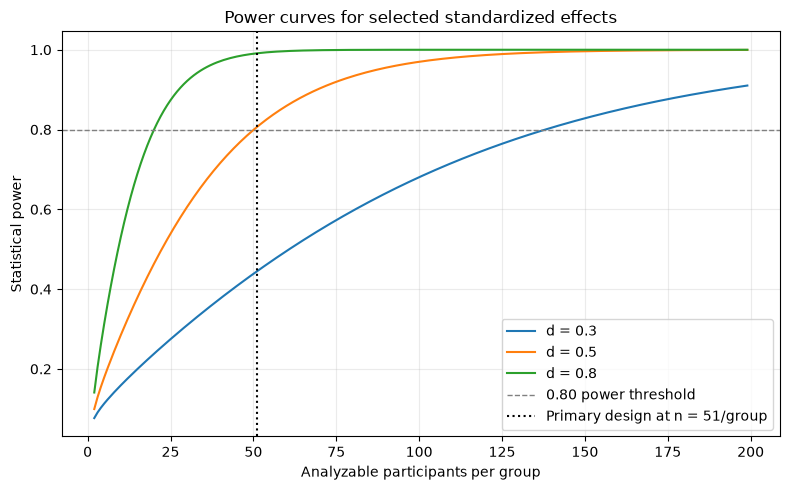

Power at n=50 per group: 0.7989
Power at n=51 per group: 0.8059
Sensitivity check: as d increases, required sample sizes decrease.


In [3]:
effect_sizes = [0.30, 0.40, 0.50, 0.60, 0.80]
rows = []
for d in effect_sizes:
    n_per_group = math.ceil(analysis.solve_power(effect_size=d, alpha=alpha, power=target_power, ratio=allocation_ratio, alternative='larger'))
    total_analyzable = 2 * n_per_group
    recruit_per_group = math.ceil(n_per_group / (1 - attrition_rate))
    total_recruit = 2 * recruit_per_group
    rows.append({
        'd': d,
        'n/group': n_per_group,
        'total analyzable': total_analyzable,
        'total recruitment': total_recruit,
    })
sensitivity = pd.DataFrame(rows)
print(sensitivity.to_string(index=False))

n_values = np.arange(1, 200)
power_by_d = {}
for d in [0.30, 0.50, 0.80]:
    power_by_d[d] = np.array([analysis.power(effect_size=d, nobs1=n, alpha=alpha, ratio=allocation_ratio, alternative='larger') for n in n_values])
fig, ax = plt.subplots(figsize=(8, 5))
for d, power in power_by_d.items():
    ax.plot(n_values, power, label=f'd = {d}')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='0.80 power threshold')
ax.axvline(51, color='black', linestyle=':', linewidth=1.5, label='Primary design at n = 51/group')
ax.set_xlabel('Analyzable participants per group')
ax.set_ylabel('Statistical power')
ax.set_title('Power curves for selected standardized effects')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

n50 = analysis.power(effect_size=d_plan, nobs1=50, alpha=alpha, ratio=1.0, alternative='larger')
n51 = analysis.power(effect_size=d_plan, nobs1=51, alpha=alpha, ratio=1.0, alternative='larger')
print(f'Power at n=50 per group: {n50:.4f}')
print(f'Power at n=51 per group: {n51:.4f}')
print('Sensitivity check: as d increases, required sample sizes decrease.')

## Conclusion and limitations

I propose a study that would require 51 analyzable employees per group and a recruitment target of 57 per group, or 114 total employees, under the specified assumptions. With the planned effect size of $d = 0.50$, the study has approximately 80% power for a one-sided independent two-sample t-test at $\alpha = 0.05$. This means the design is appropriate for the stated claim under the planning assumptions, but it does not prove that OfficeOasis products work, does not create a 80% probability that the claim is true, and does not guarantee significance in a future trial.

The design has several limitations. The literature transfer is uncertain because the source study examined green versus lean office space rather than a single small desk plant. The intervention is not fully blinded, and participants cannot be blinded to the plant. The primary outcome is a single brief work-task score rather than a broad measure of long-term productivity. I would treat task speed as an operational measure rather than a full workplace productivity metric. A speed benefit accompanied by worse accuracy would weaken the broader productivity claim. Missingness and distributional assumptions could affect inference, and a future pilot should examine variability in the chosen task before finalizing the design. If the study is implemented, the planned report would include the observed mean difference, uncertainty interval, effect size, and the prespecified t-test result.

## References

- Nieuwenhuis, M., Knight, C., Postmes, T., & Haslam, S. A. (2014). The relative benefits of green versus lean office space: Three field experiments. *Journal of Experimental Psychology: Applied, 20*(3), 199-214. DOI: https://doi.org/10.1037/xap0000024
- Green Plants for Green Buildings. (n.d.). *The Relative Benefits of Green versus Lean Office Space: Three Field Experiments.* Full text: https://greenplantsforgreenbuildings.org/wp-content/uploads/2014/09/2014GreenvsLeanOffices1-3.pdf
- University of Groningen. (n.d.). Institutional record for the study: https://research.rug.nl/en/publications/the-relative-benefits-of-green-versus-lean-office-space-three-fie/
- Statsmodels documentation for TTestIndPower: https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.solve_power.html

## Reproducibility / package versions

This study-planning analysis was generated in a fresh Python kernel. I verified the package versions shown below before running the analysis.

In [4]:
import platform
import numpy, scipy, pandas, matplotlib, statsmodels, nbformat, nbclient
print(f'Python {platform.python_version()}')
print(f'numpy {numpy.__version__}')
print(f'scipy {scipy.__version__}')
print(f'pandas {pandas.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'statsmodels {statsmodels.__version__}')
print(f'nbformat {nbformat.__version__}')
print(f'nbclient {nbclient.__version__}')


Python 3.12.3
numpy 2.5.3
scipy 1.18.1
pandas 3.0.6
matplotlib 3.11.2
statsmodels 0.15.0
nbformat 5.11.1
nbclient 0.11.0
